# Практическая работа 12 (Тест)
## Тема: Введение в машинное обучение

### Настройка окружения

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Дан набор данных [student-por.csv](./student-por.csv), содержащий информацию об успеваемости учащихся двух португальских школ. Атрибуты данных включают оценки учащихся, демографические, социальные и учебные характеристики. Подробно изучить описание атрибутов можно по [ссылке](https://archive.ics.uci.edu/dataset/320/student+performance) в источнике.

Мы будем для анализа использовать следующие характеристики:

| Атрибут               | Описание атрибута                                      | Возможные значения                                                                 |
|-----------------------|-------------------------------------------------------|-----------------------------------------------------------------------------------|
| school              | Название школы                                        | «GP» (Gabriel Pereira), «MS» (Mousinho da Silveira)                               |
| sex                 | Пол ученика                                           | «F» (женский), «M» (мужской)                                                     |
| age                 | Возраст                                               | Целые числа 15–22                                                                |
| address             | Место проживания                                      | «U» (город), «R» (пригород)                                                      |
| famsize             | Размер семьи                                          | «LE3» (≤ 3), «GT3» (> 3)                                                         |
| Medu                | Образование матери                                    | 0 (нет), 1 (4 класса), 2 (5–9), 3 (среднее), 4 (высшее)                          |
| Mjob                | Работа матери                                         | «Образование», «Медицина», «Госслужба», «Нет работы», «Другое»                   |
| traveltime          | Время в пути до школы (мин)                           | 1 (< 15), 2 (15–30), 3 (30–60), 4 (> 60)                                           |
| studytime           | Время на учебу (часы/неделю)                          | 1 (< 2), 2 (2–5), 3 (5–10), 4 (> 10)                                               |
| failures            | Кол-во учебных неудач                                 | 0–3 (3 = «3 или более»)                                                          |
| higher              | Желание получить высшее образование                                   | «no», «yes»                                                                      |
| freetime            | Свободное время после школы                           | 1 (очень мало) – 5 (очень много)                                                 |
| health              | Состояние здоровья                                    | 1 (плохо) – 5 (отлично)                                                          |
| absences            | Пропуски (дни)                                        | 0–93                                                                             |
| G1                  | Оценка за первый период                               | 0–20                                                                             |
| G2                  | Оценка за второй период                               | 0–20                                                                             |
| G3                  | Итоговая оценка (целевая переменная)                  | 0–20                                                                             |

***Важное замечание:*** целевой атрибут **G3** имеет сильную корреляцию с атрибутами **G2** и **G1**. Это происходит потому, что **G3** является итоговой оценкой за год (выставляется в 3-м периоде), в то время как **G1** и **G2** соответствуют оценкам 1-го и 2-го периодов. Без **G2** и **G1** предсказать **G3** сложнее.

Выполните чтение данных, указав характеристики, которые перечислены в таблице выше, и сохраните датафрейм в переменную *data*.

In [24]:
columns = [
    "school",
    "sex",
    "age",
    "address",
    "famsize",
    "Medu",
    "Mjob",
    "traveltime",
    "studytime",
    "failures",
    "higher",
    "freetime",
    "health",
    "absences",
    "G1",
    "G2",
    "G3",
]

data = pd.read_csv("student-por.csv", usecols=columns)
data.head(1)

,school,sex,age,address,famsize,Medu,Mjob,traveltime,studytime,failures,higher,freetime,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,4,at_home,2,2,0,yes,3,3,4,0,11,11


### Вопрос 1
Укажите общее кол-во наблюдений.

In [25]:
len(data)

649

### Вопрос 2
Выберите все категориальные признаки. Учтите, что некоторые категориальные признаки уже представлены в закодированном виде.

*Варианты ответа:*

1. address;

2. traveltime;

3. famsize;

4. absences.

*Ответ:* 1, 2, 3


### Вопрос 3
Укажите среднюю оценку за второй период. Ответ округлите до 2 знаков после запятой.

In [26]:
round(data["G2"].mean(), 2)

np.float64(11.57)

### Вопрос 4
Постройте диаграмму, которая соответствует распределению времени на учебу в зависимости от пола ученика.

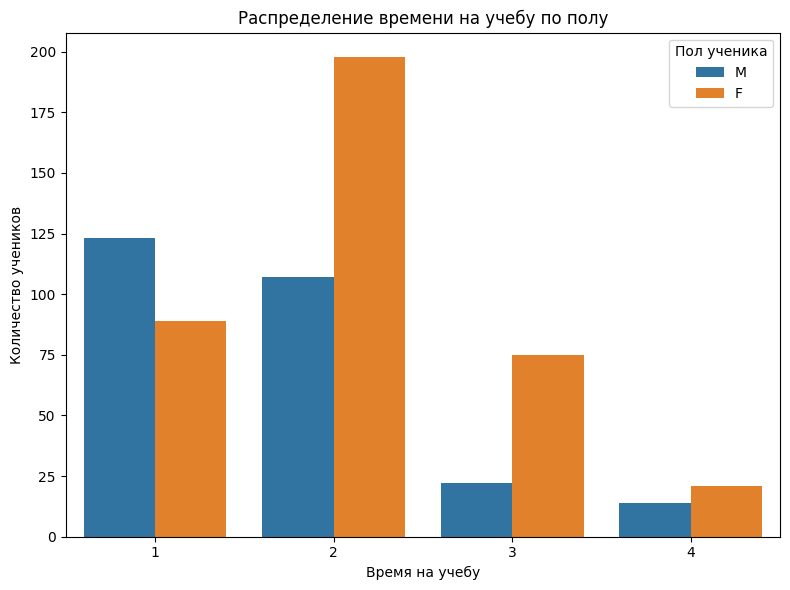

In [27]:
plt.figure(figsize=(8, 6))

sns.countplot(data=data, x="studytime", hue="sex")

plt.title("Распределение времени на учебу по полу")
plt.xlabel("Время на учебу")
plt.ylabel("Количество учеников")
plt.legend(title="Пол ученика")
plt.tight_layout()
plt.show()

### Вопрос 5
Постройте диаграмму "ящик с усами" для признака **absences** (пропуски). Выполните удаление выбросов по данному признаку (значений, находящихся выше (строго больше) уровня верхнего "уса") и сохраните результат в датафрейме для продолжения анализа.

В качестве ответа укажите кол-во выбросов для признака **absences**.

1. Построим ящик с усами

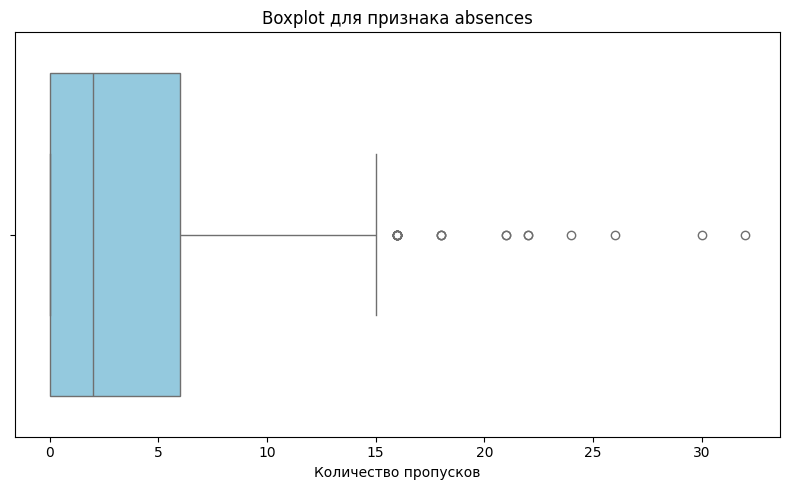

In [28]:
plt.figure(figsize=(8, 5))

sns.boxplot(x=data["absences"], color="skyblue")

plt.title("Boxplot для признака absences")
plt.xlabel("Количество пропусков")
plt.tight_layout()
plt.show()

2. Вычислим верхний "ус" и найдём выбросы

In [29]:
q1 = data['absences'].quantile(0.25)
q3 = data['absences'].quantile(0.75)
iqr = q3 - q1
upper_bound = q3 + 1.5 * iqr

outliers = data[data['absences'] > upper_bound]
num_outliers = len(outliers)

print("Количество выбросов:", num_outliers)

Количество выбросов: 21


3. Удалим выбросы и сохраним датафрейм

In [30]:
data = data[data['absences'] <= upper_bound]

### Вопрос 6
Укажите среднее значение итоговой оценки. Ответ округлите до целого.

In [31]:
round(data["G3"].mean())

12

### Вопрос 7
Укажите на сколько в среднем отклоняется значение итоговой оценки **G3** от среднего (стандартное отклонение). Ответ округлите до 2 знаков после запятой.

In [32]:
round(data["G3"].std(), 2)

np.float64(3.25)

Прежде чем создавать модели машинного обучения нам необходимо преобразовать категориальные признаки в числовую форму, потому что большинство алгоритмов машинного обучения могут работать только с числовыми данными.

В нашем наборе данных часть категориальных признаков уже закодирована, нам осталось выполнить кодирование следующих признаков: **school**, **sex**, **address**, **famsize**, **Mjob**, **higher**.

Для кодирования воспользуемся кодировщиком `OrdinalEncoder` библиотеки `sklearn`, который каждой категории присваивает уникальное числовое значение:

In [33]:
from sklearn.preprocessing import OrdinalEncoder

cat_features = ["school", "sex", "address", "famsize", "Mjob", "higher"]

encoder = OrdinalEncoder()

data[cat_features] = encoder.fit_transform(data[cat_features]) + 1

data.head(1)

,school,sex,age,address,famsize,Medu,Mjob,traveltime,studytime,failures,higher,freetime,health,absences,G1,G2,G3
0,1.0,1.0,18,2.0,1.0,4,1.0,2,2,0,2.0,3,3,4,0,11,11


### Вопрос 8
Построим модель линейной регрессии для предсказания итоговой оценки. Для отбора факторов, на основе которых будет осуществляться предсказание, вычислим корреляцию всех атрибутов с целевым - **G3**. В качестве ответа укажите корреляцию между атрибутами **higher** и **G3**. Ответ округлите до 2 знаков после запятой.

In [34]:
correlation = data.corr()

correlation_higher_g3 = correlation.loc["higher", "G3"]

print(f"Корреляция между higher и G3: {correlation_higher_g3:.2f}")

Корреляция между higher и G3: 0.33


### Вопрос 9
Отсортируйте факторы по убыванию абсолютного значения корреляции с целевой переменной -  **G3**. Отберите пять первых наиболее коррелирующих факторов (без учета факторов **G1** и **G2**) и сохраните в переменную *X*:

In [35]:
corr_g3 = correlation["G3"].drop(labels=["G3", "G1", "G2"])

top5_factors = corr_g3.abs().sort_values(ascending=False).head(5).index.tolist()

X = data[top5_factors]
y = data["G3"]

Выполним разбиение выборки на обучающую и тестовые части:

In [36]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

На данных обучающей выборки выполните создание и обучение модели линейной регрессии с помощью библиотеки `sklearn`. В качестве ответа укажите значение коэффициента при факторе **school**, округленное до 2 знаков после запятой.

In [37]:
from sklearn.linear_model import LinearRegression

model_1 = LinearRegression()
model_1.fit(X_train, y_train)

coef_school = model_1.coef_[top5_factors.index("school")]

print(f"Коэффициент при признаке school: {coef_school:.2f}")

Коэффициент при признаке school: -1.32


### Вопрос 10
Укажите кол-во факторов получившейся модели отрицательно влияющих на итоговую оценку.

In [38]:
negative_coef_count = sum(model_1.coef_ < 0)

negative_coef_count

np.int64(2)

### Вопрос 11
Оцените качество полученной модели с использованием метрики коэффициента детерминации ($R^2$). В качестве ответа укажите получившееся значение, округленное до 2 знаков после запятой.

In [39]:
from sklearn import metrics

y_pred = model_1.predict(X_test)

r2_1 = metrics.r2_score(y_test, y_pred)

round(r2_1, 2)

0.27

### Вопрос 12
Попробуем улучшить качество модели, выбрав в качестве предикторов оценки за первый и второй период. Для этого сохраним данные этих факторов в переменную *X*:

In [40]:
X = data[["G1", "G2"]]

Выполним разбиение выборки на обучающую и тестовые части:

In [41]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

На данных обучающей выборки выполните создание и обучение модели линейной регрессии с помощью библиотеки `sklearn`. В качестве ответа укажите значение коэффициента при факторе **G2**, округленное до 2 знаков после запятой.

In [42]:
model_2 = LinearRegression()
model_2.fit(X, y)

coef_g2 = model_2.coef_[1]

print(f"Коэффициент при признаке G2: {coef_g2:.2f}")

Коэффициент при признаке G2: 0.89


### Вопрос 13
Оцените качество полученной модели с использованием метрики средней квадратичной ошибки (*MSE*). В качестве ответа укажите получившееся значение, округленное до 2 знаков после запятой.

In [43]:
y_pred = model_2.predict(X_test)

mse = metrics.mean_squared_error(y_test, y_pred)

round(mse, 2)

1.62

### Вопрос 14
Выполните предсказание итоговой оценки, если оценка за 1-й период = 19, 2-й период = 17. В качестве ответа укажите округленное до целого значение.

In [44]:
X = pd.DataFrame({"G1": [19], "G2": [17]})

y_pred = model_2.predict(X)

round(y_pred[0])

18

### Вопрос 15
Выберите выводы, которые можно сделать на основе проведенного анализа.

*Варианты ответа:*

1. между временем, затрачиваемым на учебу, и итоговой оценкой наблюдается сильная корреляционная связь;

In [45]:
corr = data['studytime'].corr(data['G3'])

round(corr, 2)

np.float64(0.25)

2. 25% учеников получили итоговую оценку выше 14 баллов;

In [46]:
above_14 = len(data[data["G3"] > 14])
total_students = len(data)
percentage_above_14 = (above_14 / total_students) * 100

round(percentage_above_14, 2)

20.7

3. девочки в среднем учатся лучше мальчиков;

In [47]:
mean_scores_by_gender = data.groupby('sex')['G3'].mean()

mean_scores_by_gender

sex
1.0    12.274933
2.0    11.466926
Name: G3, dtype: float64

4. качество второй модели, основанной только на факторах оценок за 1-й и 2-й периоды, значительно выше, чем первой.

In [48]:
y_pred = model_2.predict(X_test)

r2_2 = metrics.r2_score(y_test, y_pred)

print(f"R2 первой модели: {r2_1:.2f}")
print(f"R2 второй модели: {r2_2:.2f}")

R2 первой модели: 0.27
R2 второй модели: 0.83


*Ответ:* 2, 3, 4